## 0. 목표

사전 학습 모델을 이용하여, 엑스레이 사진을 통해 폐렴 여부를 구분하는 모델을 개발한다.

## 1. 데이터 파악

### 기본 설정

In [43]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

In [44]:
import glob

# 모든 파일 경로 설정
TRAIN_NORMAL_PATHS = sorted(glob.glob("./data/train/NORMAL/*.jpeg"))
TRAIN_TARGET_PATHS = sorted(glob.glob("./data/train/PNEUMONIA/*.jpeg"))
VAL_NORMAL_PATHS = sorted(glob.glob("./data/val/NORMAL/*.jpeg"))
VAL_TARGET_PATHS = sorted(glob.glob("./data/val/PNEUMONIA/*.jpeg"))
TEST_NORMAL_PATHS = sorted(glob.glob("./data/test/NORMAL/*.jpeg"))
TEST_TARGET_PATHS = sorted(glob.glob("./data/test/PNEUMONIA/*.jpeg"))


# 폴더별 개수 출력
PATHS_DICT = {"TRAIN NORMAL": TRAIN_NORMAL_PATHS,
              "TRAIN TARGET": TRAIN_TARGET_PATHS,
              "VAL NORMAL": VAL_NORMAL_PATHS,
              "VAL TARGET": VAL_TARGET_PATHS,
              "TEST NORMAL": TEST_NORMAL_PATHS,
              "TEST TARGET": TEST_TARGET_PATHS}

print("[데이터 개수]")
for name, path in PATHS_DICT.items():
    print(f"· {name}: {len(path)}개")

[데이터 개수]
· TRAIN NORMAL: 1341개
· TRAIN TARGET: 3875개
· VAL NORMAL: 8개
· VAL TARGET: 8개
· TEST NORMAL: 234개
· TEST TARGET: 390개


- 학습 데이터의 클래스 불균형이 존재한다.

- 검증 데이터 개수가 적다.

### 오류치 확인

In [45]:
import os

# 전체 중복 파일 확인
all_folders = [set(os.listdir("./data/train/NORMAL")),
                set(os.listdir("./data/train/PNEUMONIA")),
                set(os.listdir("./data/val/NORMAL")),
                set(os.listdir("./data/val/PNEUMONIA")),
                set(os.listdir("./data/test/NORMAL")),
                set(os.listdir("./data/test/PNEUMONIA"))]

count = 0
tmp_set = set()

for folder in all_folders:
    for file_name in folder:
        if ".jpeg" in file_name:
            tmp_set.add(file_name)
            count += 1

print(f"전체 중 중복 파일: {count - len(tmp_set)}개")

전체 중 중복 파일: 0개


In [46]:
import random
import torchvision

# 샘플 이미지 기본 정보 파악
rand_index = random.randint(0, len(TRAIN_NORMAL_PATHS))

sample_normal_image = TRAIN_NORMAL_PATHS[rand_index]
sample_normal_image = torchvision.io.read_image(sample_normal_image)[0]

print(f"[샘플 이미지 정보]")
print(f"· 사이즈: {sample_normal_image.shape}")
print(f"· 클래스: {type(sample_normal_image)}")
print(f"· 데이터: {sample_normal_image.dtype}")
print(f"(ctrl+enter로 다른 이미지 정보 보기)")


[샘플 이미지 정보]
· 사이즈: torch.Size([1472, 1832])
· 클래스: <class 'torch.Tensor'>
· 데이터: torch.uint8
(ctrl+enter로 다른 이미지 정보 보기)


- 텐서 타입이다.

- uint8 타입이다.

- 각 이미지별 사이즈가 다르다.

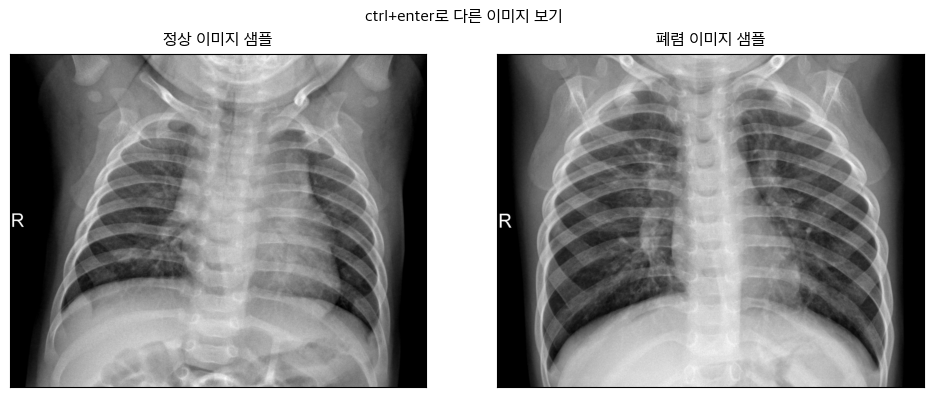

In [47]:
import torchvision
import matplotlib.pyplot as plt

# 샘플 이미지 랜덤 생성
rand_index = random.randint(0, len(TRAIN_NORMAL_PATHS))

sample_normal_image = TRAIN_NORMAL_PATHS[rand_index]
sample_target_image = TRAIN_TARGET_PATHS[rand_index]

sample_normal_image = torchvision.io.read_image(sample_normal_image)
sample_target_image = torchvision.io.read_image(sample_target_image)


# 축 숫자 표기 제거 함수 생성
def remove_ticks(columns=2):
    for num in range(columns):
        axes[num].set_xticks([])
        axes[num].set_yticks([])


# 샘플 이미지 출력
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
remove_ticks()

axes[0].imshow(sample_normal_image[0], cmap="gray")
axes[1].imshow(sample_target_image[0], cmap="gray")

fig.suptitle("ctrl+enter로 다른 이미지 보기")
axes[0].set_title("정상 이미지 샘플")
axes[1].set_title("폐렴 이미지 샘플")

plt.tight_layout()
plt.show()

- 폐렴 환자의 폐 부근이 전반적으로 더욱 뿌옇다는 사실을 알 수 있다.

- 사진 각각의 사이즈가 모두 다르다는 것을 알 수 있다. 이는 사전 학습 모델이 사이즈 조절을 하므로 그대로 진행한다.

### 고려 사항

1. 사전 모델 선정

    이미지 분류에는 ResNet, VGG, MobileNet이 주로 활용된다.

    이 중 가장 우수하다고 알려져 있는 ResNet을 이용한다.

2. 학습 데이터의 클래스 불균형 

   샘플러를 활용한다. 비율에 반비례하는 가중치를 부여하여 같은 횟수로 학습할 수 있도록 유도한다.

3. 검증 데이터 개수 부족

    |방식|소요 시간|기대 성능|
    |---|---|---|
    |사전모델에 의존|·|하|
    |학습데이터 일부 활용|중|중|
    |K-fold|상|상|

    효율적인 시간 활용을 위해, 학습 데이터 일부를 검증 데이터로 활용, 평가 후 K-Fold를 추가로 운용할지 판단한다.

    기존 검증 데이터는 작은 수로 통계적 의미가 없으므로, 이번 실험에서는 이용하지 않는다.

4. 성능 평가 기준

    분류와 더불어 질병 포착 모델이므로, 재현율이 가장 중요하다.

5. 기타

    사전학습 모델을 이용하므로, 활성화 함수나 손실 함수 등의 추가적인 선정 없이 그대로 이용한다.

## 2. 실험 진행

### 실험 설계

1. ResNet152 모델은 입력층이 3채널로, 1채널인 학습 데이터와 맞지 않으므로 두 가지 방향으로 진행한다.

    - Ch3 모델: 학습 데이터 채널을 1채널에서 3채널로 바꾼다.

    - Ch1 모델: 사전 학습 모델의 입력층 채널을 3채널에서 1채널로 바꾼다.

2. Ch3 모델과 Ch1 모델의 Frozen 성능 평가를 통해 기본 모델을 설정한다.

3. 기본 모델 기반 Partial·Full Fine-tuning을 진행한다.

4. 테스트 결과에 따라 K-fold 적용 여부를 결정하여 진행한다.

In [48]:
# 모델 설정
MODEL = torchvision.models.resnet152(weights='IMAGENET1K_V1')

# 모델의 주요 레이어 확인
print("[ResNet152 모델 주요 레이어]")

for n, (name, module) in enumerate(MODEL.named_children()):
    print(f"{n}) {name}: {module.__class__.__name__}")

# 입력과 출력층 확인
print("\n[입력층과 출력층]")
print(f"· 입력층: {MODEL.conv1}")
print(f"· 출력층: {MODEL.fc}")

[ResNet152 모델 주요 레이어]
0) conv1: Conv2d
1) bn1: BatchNorm2d
2) relu: ReLU
3) maxpool: MaxPool2d
4) layer1: Sequential
5) layer2: Sequential
6) layer3: Sequential
7) layer4: Sequential
8) avgpool: AdaptiveAvgPool2d
9) fc: Linear

[입력층과 출력층]
· 입력층: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
· 출력층: Linear(in_features=2048, out_features=1000, bias=True)


In [49]:
import copy
from torchvision.transforms import v2
from torchvision.transforms import InterpolationMode

# 채널별 device·모델 설정
CH_3_MODEL, CH_3_DEVICE  = copy.deepcopy(MODEL), DEVICE
CH_1_MODEL, CH_1_DEVICE  = copy.deepcopy(MODEL), DEVICE


# 채널별 변환기 설정
CH_3_TRANSFORM = torchvision.models.ResNet152_Weights.IMAGENET1K_V1.transforms()
CH_1_TRANSFORM = v2.Compose([
        v2.Grayscale(num_output_channels=1), # 입력 채널 1개로 변경.
        v2.Resize(256, interpolation=InterpolationMode.BILINEAR),
        v2.CenterCrop(224),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.449], # 기존 3채널 값의 평균값 활용
                     std=[0.226])])
        # (1채널 변환기 참고 자료: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet152.html#torchvision.models.ResNet152_Weights)

In [50]:
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

# 채널별 데이터셋 설정
CH_3_TRAIN_DATASET = ImageFolder(root = "./data/train", transform=CH_3_TRANSFORM)
CH_1_TRAIN_DATASET = ImageFolder(root = "./data/train", transform=CH_1_TRANSFORM)

CH_3_TEST_DATASET = ImageFolder(root = "./data/test", transform=CH_3_TRANSFORM)
CH_1_TEST_DATASET = ImageFolder(root = "./data/test", transform=CH_1_TRANSFORM)


# 훈련·검증 데이터 분할
train_indices, val_indices = train_test_split(
    list(range(len(CH_3_TRAIN_DATASET))),
    test_size=0.2,
    stratify=CH_3_TRAIN_DATASET.targets
)

ch_3_train_subset = Subset(CH_3_TRAIN_DATASET, train_indices)
ch_1_train_subset = Subset(CH_1_TRAIN_DATASET, train_indices)
ch_3_val_subset = Subset(CH_3_TRAIN_DATASET, val_indices)
ch_1_val_subset = Subset(CH_1_TRAIN_DATASET, val_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(CH_3_TRAIN_DATASET)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(CH_3_TRAIN_DATASET) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(CH_3_TRAIN_DATASET) * 100:.2f}%)")


# 샘플러 설정
labels = torch.tensor([CH_3_TRAIN_DATASET.targets[i] for i in train_indices])

class_counts = torch.bincount(labels)
class_weights = 1. / class_counts.float()
samples_weights = class_weights[labels]

ch_3_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True)

ch_1_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True)

print(f"· 학습 데이터 중 일반 클래스: {(len(labels) - labels.sum())}개 ({(len(labels) - labels.sum()) / len(labels) * 100:.2f}%)")
print(f"· 학습 데이터 중 폐렴 클래스: {labels.sum()}개 ({labels.sum() / len(labels) * 100:.2f}%)")
print(f"\n[가중치]")
print(f"· 일반 클래스: {class_weights[0]:.4f}")
print(f"· 폐렴 클래스: {class_weights[1]:.4f}")


# 채널별 데이터 로더 설정
CH_3_TRAIN_DATALOADER = DataLoader(ch_3_train_subset, batch_size=64, sampler=ch_3_sampler, shuffle=False, num_workers=4)
CH_1_TRAIN_DATALOADER = DataLoader(ch_1_train_subset, batch_size=64, sampler=ch_1_sampler, shuffle=False, num_workers=4)

CH_3_VAL_DATALOADER = DataLoader(ch_3_val_subset, batch_size=64, shuffle=False, num_workers=4)
CH_1_VAL_DATALOADER = DataLoader(ch_1_val_subset, batch_size=64, shuffle=False, num_workers=4)

CH_3_TEST_DATALOADER = DataLoader(CH_3_TEST_DATASET, batch_size=64, shuffle=False, num_workers=4)
CH_1_TEST_DATALOADER = DataLoader(CH_1_TEST_DATASET, batch_size=64, shuffle=False, num_workers=4)

[분할 결과]
· 기존 학습 데이터: 5216개
· 분할 후 학습 데이터: 4172개 (79.98%)
· 분할 후 검증 데이터: 1044개 (20.02%)
· 학습 데이터 중 일반 클래스: 1073개 (25.72%)
· 학습 데이터 중 폐렴 클래스: 3099개 (74.28%)

[가중치]
· 일반 클래스: 0.0009
· 폐렴 클래스: 0.0003


### 3채널 기본 모델 설정

1. 가중치 학습 비활성화(추후 모델 생성시 필요한 부분만 활성화)

2. 데이터의 채널 1 -> 3: 기존 transform을 이용하면 자동으로 3채널로 변경된다. (완료)

3. 출력층의 클래스 개수 1000 -> 2

In [51]:
import torch.nn as nn

# 가중치 학습 비활성화
for param in CH_3_MODEL.parameters():
    param.requires_grad = False

# 출력층 수정
in_features = CH_3_MODEL.fc.in_features
CH_3_MODEL.fc = nn.Linear(in_features=in_features, out_features=2) # 1000 -> 2

# 입력과 출력층
print("[3채널 입력층과 출력층]")
print(f"· 입력층: {CH_3_MODEL.conv1}")
print(f"· 출력층: {CH_3_MODEL.fc}")

[3채널 입력층과 출력층]
· 입력층: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
· 출력층: Linear(in_features=2048, out_features=2, bias=True)


### 3채널 Frozen 모델 생성

In [52]:
ch_3_fr_model, ch_3_fr_device = copy.deepcopy(CH_3_MODEL), CH_3_DEVICE

In [53]:
import torch.optim as optim

# 손실함수
CRITERION = nn.CrossEntropyLoss()

# 모델·옵티마이저 설정
print("[3채널 재학습 레이어]")
params_to_update = []
for name, param in ch_3_fr_model.named_parameters():
    if param.requires_grad:
        params_to_update.append(param)
        print(f"· {name}")

# 디바이스
ch_3_fr_model = ch_3_fr_model.to(ch_3_fr_device)

# 옵티마이저 할당
ch_3_fr_optim = optim.Adam(params_to_update, lr=0.0005)

[3채널 재학습 레이어]
· fc.weight
· fc.bias


### 1채널 기본 모델 설정

1. 가중치 학습 비활성화(추후 모델 생성시 필요한 부분만 활성화)

2. Conv1 레이어의 채널 3 -> 1

3. 출력층의 클래스 개수 1000 -> 2

In [54]:
# 입력과 출력층
print("[1채널 입력층과 출력층]")
print(f"· 입력층: {CH_1_MODEL.conv1}")
print(f"· 출력층: {CH_1_MODEL.fc}")

[1채널 입력층과 출력층]
· 입력층: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
· 출력층: Linear(in_features=2048, out_features=1000, bias=True)


In [55]:
# 가중치 학습 비활성화
for param in CH_1_MODEL.parameters():
    param.requires_grad = False

# conv1(입력 레이어)의 채널 3 -> 1
old_weights = CH_1_MODEL.conv1.weight.data
CH_1_MODEL.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
with torch.no_grad():
    CH_1_MODEL.conv1.weight.data = old_weights.mean(dim=1, keepdim=True)

# 출력층 수정
in_features = CH_1_MODEL.fc.in_features
CH_1_MODEL.fc = nn.Linear(in_features=in_features, out_features=2) # 1000 -> 2

### 1채널 Frozen 모델 생성

In [56]:
ch_1_fr_model, ch_1_fr_device = copy.deepcopy(CH_1_MODEL), CH_1_DEVICE

In [57]:
# 모델·옵티마이저 설정
print("[재학습 레이어]")
params_to_update = []
for name, param in ch_1_fr_model.named_parameters():
    if param.requires_grad:
        params_to_update.append(param)
        print(f"· {name}")

# 디바이스
ch_1_fr_model = ch_1_fr_model.to(ch_1_fr_device)

# 옵티마이저 할당
ch_1_fr_optim = optim.Adam(params_to_update, lr=0.0005)

[재학습 레이어]
· conv1.weight
· fc.weight
· fc.bias


### 3채널 모델 - 1채널 모델 성능 비교

In [58]:
last_epoch = sorted(os.listdir("./checkpoints"))
last_epoch

a = []
for i in last_epoch:
    if i.startswith("Ch_1"):
        a.append(i)
        a.append(i.split(".")[0].split("_")[3])
    
print(a)

a

['Ch_1_Frozen_01.pth', '01', 'Ch_1_Frozen_02.pth', '02', 'Ch_1_Frozen_03.pth', '03', 'Ch_1_Frozen_04.pth', '04']


['Ch_1_Frozen_01.pth',
 '01',
 'Ch_1_Frozen_02.pth',
 '02',
 'Ch_1_Frozen_03.pth',
 '03',
 'Ch_1_Frozen_04.pth',
 '04']

In [59]:
type(ch_3_fr_optim)

torch.optim.adam.Adam

In [60]:
# 체크포인트 저장 함수 생성
def save_checkpoint(name: str, epoch, model, optimizer, loss):

    """
    weight, bias 등 모델 파라미터만 저장합니다.
    학습, 검증, 테스트 결과는 result_df에 저장합니다.
    """

    if not os.path.exists("./checkpoints"):
        os.makedirs("./checkpoints")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss 
    }

    torch.save(checkpoint, f"./checkpoints/{name}_{epoch:02d}.pth")


def load_checkpoint(name, model, optimizer):
    
    model = model
    optimizer = optimizer

    if not os.path.exists("./checkpoints") or len(os.listdir("./checkpoints")) == 0:
        return model, optimizer, 0
    
    checkpoint_list = sorted(os.listdir("./checkpoints"))
    epoch_list = []
    
    for file_name in checkpoint_list:
        if file_name.startswith(name) and file_name.endswith(".pth"):
            epoch_str = file_name.replace(".pth", "").split("_")[-1]
            epoch_list.append(int(epoch_str))

    if not epoch_list:
        return model, optimizer, 0

    start_epoch = max(epoch_list)

    checkpoint = torch.load(f"./checkpoints/{name}_{start_epoch:02d}.pth")
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return model, optimizer, start_epoch

In [61]:
# 결과 저장용 데이터프레임 생성
import pandas as pd

result_df = pd.DataFrame(columns=["Name", "Mode", "Epoch", "Loss", "F1", "Recall", "Acc", "Prec"])

# 체크포인트 저장 함수 생성
def save_checkpoint(name: str, epoch, model, optimizer, loss):

    """
    weight, bias 등 모델 파라미터만 저장합니다.
    학습, 검증, 테스트 결과는 result_df에 저장합니다.
    """

    if not os.path.exists("./checkpoints"):
        os.makedirs("./checkpoints")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss 
    }

    torch.save(checkpoint, f"./checkpoints/{name}_{epoch:02d}.pth")


# 체크포인트 로드 함수 생성(체크포인트 없어도 사용 가능)
def load_checkpoint(name, model, optimizer):
    
    model = model
    optimizer = optimizer

    if not os.path.exists("./checkpoints") or len(os.listdir("./checkpoints")) == 0:
        return model, optimizer, 0
    
    checkpoint_list = sorted(os.listdir("./checkpoints"))
    epoch_list = []
    
    for file_name in checkpoint_list:
        if file_name.startswith(name) and file_name.endswith(".pth"):
            epoch_str = file_name.replace(".pth", "").split("_")[-1]
            epoch_list.append(int(epoch_str))

    if not epoch_list:
        return model, optimizer, 0

    start_epoch = max(epoch_list)

    checkpoint = torch.load(f"./checkpoints/{name}_{start_epoch:02d}.pth")
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return model, optimizer, start_epoch

In [62]:
import torchmetrics

# 학습 함수 설정
def train_model(model, dataloader, optimizer, device):
    model.train()

    train_loss = 0.0
    f1_score = torchmetrics.F1Score(task="binary").to(device)
    recall = torchmetrics.Recall(task="binary").to(device)
    accuracy = torchmetrics.Accuracy(task="binary").to(device)
    precision = torchmetrics.Precision(task="binary").to(device)

    for Xs, ys in dataloader:
        Xs = Xs.to(device)
        ys = ys.to(device)

        optimizer.zero_grad()

        y_preds = model(Xs)

        loss = CRITERION(y_preds, ys)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        label_preds = torch.argmax(y_preds, dim=1)
        f1_score.update(label_preds, ys)
        recall.update(label_preds, ys)
        accuracy.update(label_preds, ys)
        precision.update(label_preds, ys)

    epoch_loss = train_loss / len(dataloader)
    epoch_f1_score = (f1_score.compute()).item()
    epoch_recall = (recall.compute()).item()
    epoch_accuracy = (accuracy.compute()).item()
    epoch_precision = (precision.compute()).item()

    return [epoch_loss, epoch_f1_score, epoch_recall, epoch_accuracy, epoch_precision]


# 검증, 테스트 함수 설정
def eval_model(model, dataloader, device):
    model.eval()

    eval_loss = 0.0
    f1_score = torchmetrics.F1Score(task="binary").to(device)
    recall = torchmetrics.Recall(task="binary").to(device)
    accuracy = torchmetrics.Accuracy(task="binary").to(device)
    precision = torchmetrics.Precision(task="binary").to(device)

    with torch.no_grad():
        for Xs, ys in dataloader:
            Xs = Xs.to(device)
            ys = ys.to(device)

            y_preds = model(Xs)

            loss = CRITERION(y_preds, ys)
            eval_loss += loss.item()

            label_preds = torch.argmax(y_preds, dim=1)
            f1_score.update(label_preds, ys)
            recall.update(label_preds, ys)
            accuracy.update(label_preds, ys)
            precision.update(label_preds, ys)

    epoch_loss = eval_loss / len(dataloader)
    epoch_f1_score = (f1_score.compute()).item()
    epoch_recall = (recall.compute()).item()
    epoch_accuracy = (accuracy.compute()).item()
    epoch_precision = (precision.compute()).item()

    return [epoch_loss, epoch_f1_score, epoch_recall, epoch_accuracy, epoch_precision]

In [ ]:
# 3채널 Frozen 모델 학습 및 성능 평가

clean_cache()

num_epochs = 5
# val_flag = False

mode = "Ch_3_Frozen"
model = ch_3_fr_model
optimizer = ch_3_fr_optim
device = ch_3_fr_device

model, optimizer, start_epoch = load_checkpoint(mode, model, optimizer)

print(f"start_epoch: {start_epoch+1}")

for epoch in range(start_epoch, num_epochs):

    # 훈련
    # if val_flag == True: break

    train_result_list = train_model(dataloader=CH_3_TRAIN_DATALOADER, model=model, optimizer=optimizer, device=device)
    result_df.loc[len(result_df)] = [mode, "Train", epoch+1, train_result_list[0], train_result_list[1], train_result_list[2], train_result_list[3], train_result_list[4]]

    # 검증
    val_result_list = eval_model(dataloader=CH_3_VAL_DATALOADER, model=model, device=device)
    result_df.loc[len(result_df)] = [mode, "Val", epoch+1, val_result_list[0], val_result_list[1], val_result_list[2], val_result_list[3], val_result_list[4]]

    # if len(ch_3_fr_val_losses) > 1:
    #     if ch_3_fr_val_losses[-1] > ch_3_fr_val_losses[-2]:
    #         val_flag = True

    # 테스트
    test_result_list = eval_model(dataloader=CH_3_TEST_DATALOADER, model=model, device=device)
    result_df.loc[len(result_df)] = [mode, "Test", epoch+1, test_result_list[0], test_result_list[1], test_result_list[2], test_result_list[3], test_result_list[4]]

    # 체크포인트 저장: 테스트 데이터까지 result_df에 기록된 후 진행.
    save_checkpoint(mode, epoch+1, model, optimizer, train_result_list[0])
    
clean_cache()

2


In [68]:
result_df.sort_values("Mode")

,Name,Mode,Epoch,Loss,F1,Recall,Acc,Prec
2,Ch_3_Frozen,Test,1,0.611677,0.793878,0.997436,0.676282,0.659322
5,Ch_3_Frozen,Test,2,0.336633,0.891960,0.910256,0.862179,0.874384
8,Ch_3_Frozen,Test,3,0.357792,0.892601,0.958974,0.855769,0.834821
11,Ch_3_Frozen,Test,4,0.498392,0.849285,0.989744,0.780449,0.743738
14,Ch_3_Frozen,Test,5,0.355023,0.896057,0.961538,0.860577,0.838926
0,Ch_3_Frozen,Train,1,0.371119,0.856716,0.826442,0.862176,0.889291
3,Ch_3_Frozen,Train,2,0.210091,0.929138,0.911522,0.931448,0.947448
6,Ch_3_Frozen,Train,3,0.170467,0.937862,0.915071,0.940796,0.961816
9,Ch_3_Frozen,Train,4,0.163862,0.941060,0.927114,0.942713,0.955433
12,Ch_3_Frozen,Train,5,0.142213,0.951493,0.940526,0.950144,0.962718


In [ ]:
# 1채널 Frozen 모델 학습 및 성능 평가

clean_cache()

num_epochs = 5
# val_flag = False

mode = "Ch_1_Frozen"
model = ch_1_fr_model
optimizer = ch_1_fr_optim
device = ch_1_fr_device

model, optimizer, start_epoch = load_checkpoint(mode, model, optimizer)

print(f"[학습 시작]")
print(f"mode: {mode}")
print(f"start_epoch: {start_epoch+1}")

for epoch in range(start_epoch, num_epochs):

    # 훈련
    # if val_flag == True: break

    train_result_list = train_model(dataloader=CH_1_TRAIN_DATALOADER, model=model, optimizer=optimizer, device=device)
    result_df.loc[len(result_df)] = [mode, "Train", epoch+1, train_result_list[0], train_result_list[1], train_result_list[2], train_result_list[3], train_result_list[4]]

    # 검증
    val_result_list = eval_model(dataloader=CH_1_VAL_DATALOADER, model=model, device=device)
    result_df.loc[len(result_df)] = [mode, "Val", epoch+1, val_result_list[0], val_result_list[1], val_result_list[2], val_result_list[3], val_result_list[4]]

    # if len(ch_1_fr_val_losses) > 1:
    #     if ch_1_fr_val_losses[-1] > ch_1_fr_val_losses[-2]:
    #         val_flag = True

    # 테스트
    test_result_list = eval_model(dataloader=CH_1_TEST_DATALOADER, model=model, device=device)
    result_df.loc[len(result_df)] = [mode, "Test", epoch+1, test_result_list[0], test_result_list[1], test_result_list[2], test_result_list[3], test_result_list[4]]

    # 체크포인트 저장: 테스트 데이터까지 result_df에 기록된 후 진행.
    save_checkpoint(mode, epoch+1, model, optimizer, train_result_list[0])
    
clean_cache()

python(16251) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16278) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16279) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16356) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16357) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16416) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16419) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(16433) Malloc

In [ ]:
result_df.sort_values(["Mode", "Name"])

성능 차이가 크지 않으므로, 소요 시간 측면에서 1채널 모델로 실험을 진행한다.

### 3채널 Partial Fine-tuning 모델

In [ ]:
def show_feature(name, out, max_channels=8):
    fmap = out.squeeze(0).detach().cpu()
    num = min(max_channels, fmap.shape[0])
    fig, axes = plt.subplots(1, num, figsize=(15,4))

    for i, ax in enumerate(axes if num>1 else [axes]):
        ax.imshow(fmap[i], cmap="gray")
        ax.axis("off")

    print(f" {name} → {tuple(out.shape)}")
    plt.show()


ch_3_sample_image = CH_3_TRAIN_DATASET[0][0].to(CH_3_DEVICE)

layers_dict = dict(CH_3_MODEL.named_children())


out = ch_3_sample_image.unsqueeze(0)
for layer in ["conv1", "layer1", "layer2","layer3","layer4"]:
    out = layers_dict[layer](out)
    show_feature(layer, out)

layer3부터 특징이 뚜렷하지 않으므로 재학습 시점으로 설정한다.

In [ ]:
ch_3_pa_model, ch_3_pa_device = copy.deepcopy(CH_3_MODEL), CH_3_DEVICE

In [ ]:
# 모델·옵티마이저 설정
print("[재학습 레이어]")
params_to_update = []
for name, param in ch_3_pa_model.named_parameters():
    if name.startswith(("layer3", "layer4", "fc")):
        param.requires_grad = True
        params_to_update.append(param)
        print(f"· {name}") # 학습시킬 파라미터 이름 확인
    else:
        param.requires_grad = False


# 디바이스
ch_3_pa_model = ch_3_pa_model.to(ch_3_pa_device)

# 옵티마이저 할당
ch_3_pa_optim = optim.Adam(params_to_update, lr=0.0005)

In [ ]:
# 3채널 Partial Fine-tuning 모델 학습 및 성능 평가

clean_cache()

num_epochs = 5

# val_flag = False

for epoch in range(num_epochs):

    # 훈련
    # if val_flag == True: break

    train_result_list = train_model(model=ch_3_pa_model,
                                    dataloader=CH_3_TRAIN_DATALOADER,
                                    optimizer=ch_3_pa_optim,
                                    device=ch_3_pa_device)

    result_df.loc[len(result_df)] = ["Ch_3_Partial", "Train", epoch+1, train_result_list[0], train_result_list[1], train_result_list[2], train_result_list[3], train_result_list[4]]


    # 검증
    val_result_list = eval_model(model=ch_3_pa_model,
                                 dataloader=CH_3_VAL_DATALOADER,
                                 device=ch_3_pa_device)

    result_df.loc[len(result_df)] = ["Ch_3_Partial", "Val", epoch+1, val_result_list[0], val_result_list[1], val_result_list[2], val_result_list[3], val_result_list[4]]


    # if len(ch_3_pa_val_losses) > 1:
    #     if ch_3_pa_val_losses[-1] > ch_3_pa_val_losses[-2]:
    #         val_flag = True

    # 테스트
    test_result_list = eval_model(model=ch_3_pa_model,
                                  dataloader=CH_3_TEST_DATALOADER,
                                  device=ch_3_pa_device)

    result_df.loc[len(result_df)] = ["Ch_3_Partial", "Test", epoch+1, test_result_list[0], test_result_list[1], test_result_list[2], test_result_list[3], test_result_list[4]]


clean_cache()

### 3채널 Full Fine-tuning 모델

In [ ]:
ch_3_full_model, ch_3_full_device = copy.deepcopy(CH_3_MODEL), CH_3_DEVICE

In [ ]:
# 모델·옵티마이저 설정
params_to_update = []
for param in ch_3_full_model.parameters():
    param.requires_grad = True

# 디바이스
ch_3_full_model = ch_3_full_model.to(ch_3_full_device)

# 옵티마이저 할당
ch_3_full_optim = optim.Adam(ch_3_full_model.parameters(), lr=0.0005)

In [ ]:
# 3채널 Full Fine-tuning 모델 학습 및 성능 평가

clean_cache()

num_epochs = 5

# val_flag = False

for epoch in range(num_epochs):

    # 훈련
    # if val_flag == True: break

    train_result_list = train_model(model=ch_3_full_model,
                                    dataloader=CH_3_TRAIN_DATALOADER,
                                    optimizer=ch_3_full_optim,
                                    device=ch_3_full_device)

    result_df.loc[len(result_df)] = ["Ch_3_Full", "Train", epoch+1, train_result_list[0], train_result_list[1], train_result_list[2], train_result_list[3], train_result_list[4]]


    # 검증
    val_result_list = eval_model(model=ch_3_full_model,
                                 dataloader=CH_3_VAL_DATALOADER,
                                 device=ch_3_full_device)

    result_df.loc[len(result_df)] = ["Ch_3_Full", "Val", epoch+1, val_result_list[0], val_result_list[1], val_result_list[2], val_result_list[3], val_result_list[4]]


    # if len(ch_3_full_val_losses) > 1:
    #     if ch_3_full_val_losses[-1] > ch_3_full_val_losses[-2]:
    #         val_flag = True

    # 테스트
    test_result_list = eval_model(model=ch_3_full_model,
                                  dataloader=CH_3_TEST_DATALOADER,
                                  device=ch_3_full_device)

    result_df.loc[len(result_df)] = ["Ch_3_Full", "Test", epoch+1, test_result_list[0], test_result_list[1], test_result_list[2], test_result_list[3], test_result_list[4]]


clean_cache()

## 1채널 모델

In [ ]:
# 모델의 주요 레이어 확인
print("[1채널 모델 주요 레이어]")
for n, (name, module) in enumerate(CH_1_MODEL.named_children()):
    print(f"{n}) {name}: {module.__class__.__name__}")

# 입력과 출력층
print("\n[1채널 입력층과 출력층]")
print(f"· 입력층: {CH_1_MODEL.conv1}")
print(f"· 출력층: {CH_1_MODEL.fc}")

In [ ]:
# 기본값 설정
for param in CH_1_MODEL.parameters():
    param.requires_grad = False

# conv1(입력 레이어)의 3채널 -> 1채널
old_weights = CH_1_MODEL.conv1.weight.data
CH_1_MODEL.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) # 시그모이드로 하는 건 여기가 아닌가?
with torch.no_grad():
    CH_1_MODEL.conv1.weight.data = old_weights.mean(dim=1, keepdim=True)

# 출력층 수정
in_features = CH_1_MODEL.fc.in_features
CH_1_MODEL.fc = nn.Linear(in_features=in_features, out_features=2) # 1000 -> 2

### Frozen

In [ ]:
# ch_1_fr_model, ch_1_fr_device = copy.deepcopy(CH_1_MODEL), CH_1_DEVICE

In [ ]:
# # 모델·옵티마이저 설정
# print("[재학습 레이어]")
# params_to_update = []
# for name, param in ch_1_fr_model.named_parameters():
#     if param.requires_grad:
#         params_to_update.append(param)
#         print(f"· {name}")

# # 디바이스
# ch_1_fr_model = ch_1_fr_model.to(ch_1_fr_device)

# # 옵티마이저 할당
# ch_1_fr_optim = optim.Adam(params_to_update, lr=0.0005)

In [ ]:
# # 1채널 Frozen 모델 학습 및 성능 평가

# clean_cache()

# num_epochs = 5

# ch_1_fr_train_losses, ch_1_fr_val_losses, ch_1_fr_test_losses = [], [], []
# ch_1_fr_train_accuracies, ch_1_fr_val_accuracies, ch_1_fr_test_accuracies = [], [], []

# # val_flag = False

# for epoch in range(num_epochs):

#     # 훈련

#     # if val_flag == True: break

#     epoch_train_loss, epoch_train_acc = train_model(model=ch_1_fr_model,
#                                                     dataloader=CH_1_TRAIN_DATALOADER,
#                                                     optimizer=ch_1_fr_optim,
#                                                     device=ch_1_fr_device)

#     ch_1_fr_train_losses.append(epoch_train_loss)
#     ch_1_fr_train_accuracies.append(epoch_train_acc)


#     # 검증
#     epoch_val_loss, epoch_val_acc = eval_model(model=ch_1_fr_model,
#                                                dataloader=CH_1_VAL_DATALOADER,
#                                                device=ch_1_fr_device)

#     ch_1_fr_val_losses.append(epoch_val_loss)
#     ch_1_fr_val_accuracies.append(epoch_val_acc)

#     # if len(ch_1_fr_val_losses) > 1:
#     #     if ch_1_fr_val_losses[-1] > ch_1_fr_val_losses[-2]:
#     #         val_flag = True

#     # 테스트
#     epoch_test_loss, epoch_test_acc = eval_model(model=ch_1_fr_model,
#                                                  dataloader=CH_1_TEST_DATALOADER,
#                                                  device=ch_1_fr_device)

#     ch_1_fr_test_losses.append(epoch_test_loss)
#     ch_1_fr_test_accuracies.append(epoch_test_acc)


#     # 로그 출력
#     print(f"[Epoch {epoch+1}] "
#             f"Train Loss: {epoch_train_loss:.4f} | "
#             f"Train Acc: {epoch_train_acc*100:.2f}% | "
#             f"Val Loss: {epoch_val_loss:.4f} | "
#             f"Val Acc: {epoch_val_acc*100:.2f}% | "
#             f"Test Loss: {epoch_test_loss:.4f} | "
#             f"Test Acc: {epoch_test_acc*100:.2f}%")


# clean_cache()

### Partial

In [ ]:
# # 샘플 이미지 통해 레이어 정하기
# ch_1_sample_image = CH_1_TRAIN_DATASET[0][0].to(CH_1_DEVICE)

# x = ch_1_sample_image.unsqueeze(0)
# layers = dict(CH_1_MODEL.named_children())

# out = x
# for name in ["conv1", "layer1", "layer2","layer3","layer4"]:
#     out = layers[name](out)
#     show_feature(name, out)

In [ ]:
# ch_1_pa_model, ch_1_pa_device = copy.deepcopy(CH_1_MODEL), CH_1_DEVICE

In [ ]:
# # 모델·옵티마이저 설정
# print("[재학습 레이어]")
# params_to_update = []
# for name, param in ch_1_pa_model.named_parameters():
#     if name.startswith(("conv1", "layer3", "layer4", "fc")):
#         param.requires_grad = True
#         params_to_update.append(param)
#         print(f"· {name}") # 학습시킬 파라미터 이름 확인
#     else:
#         param.requires_grad = False


# # 디바이스
# ch_1_pa_model = ch_1_pa_model.to(ch_1_pa_device)

# # 옵티마이저 할당
# ch_1_pa_optim = optim.Adam(params_to_update, lr=0.0005)

동일하게 layer 2까지 쓰고, layer 3부터 재학습을 실시한다.

단, 기존의 입력층에 해당하는 conv2d의 입력 채널이 3에서 1로 바뀌었기 때문에 재학습이 필요하다.

In [ ]:
# clean_cache()

# num_epochs = 5

# ch_1_pa_train_losses, ch_1_pa_val_losses, ch_1_pa_test_losses = [], [], []
# ch_1_pa_train_accuracies, ch_1_pa_val_accuracies, ch_1_pa_test_accuracies = [], [], []

# # val_flag = False

# for epoch in range(num_epochs):

#     # 훈련

#     # if val_flag == True: break

#     epoch_train_loss, epoch_train_acc = train_model(model=ch_1_pa_model,
#                                                     dataloader=CH_1_TRAIN_DATALOADER,
#                                                     optimizer=ch_1_pa_optim,
#                                                     device=ch_1_pa_device)

#     ch_1_pa_train_losses.append(epoch_train_loss)
#     ch_1_pa_train_accuracies.append(epoch_train_acc)


#     # 검증
#     epoch_val_loss, epoch_val_acc = eval_model(model=ch_1_pa_model,
#                                                dataloader=CH_1_VAL_DATALOADER,
#                                                device=ch_1_pa_device)

#     ch_1_pa_val_losses.append(epoch_val_loss)
#     ch_1_pa_val_accuracies.append(epoch_val_acc)

#     # if len(ch_1_pa_val_losses) > 1:
#     #     if ch_1_pa_val_losses[-1] > ch_1_pa_val_losses[-2]:
#     #         val_flag = True

#     # 테스트
#     epoch_test_loss, epoch_test_acc = eval_model(model=ch_1_pa_model,
#                                                  dataloader=CH_1_TEST_DATALOADER,
#                                                  device=ch_1_pa_device)

#     ch_1_pa_test_losses.append(epoch_test_loss)
#     ch_1_pa_test_accuracies.append(epoch_test_acc)


#     # 로그 출력
#     print(f"[Epoch {epoch+1}] "
#             f"Train Loss: {epoch_train_loss:.4f} | "
#             f"Train Acc: {epoch_train_acc*100:.2f}% | "
#             f"Val Loss: {epoch_val_loss:.4f} | "
#             f"Val Acc: {epoch_val_acc*100:.2f}% | "
#             f"Test Loss: {epoch_test_loss:.4f} | "
#             f"Test Acc: {epoch_test_acc*100:.2f}%")


# clean_cache()

소요 시간과 성능의 측면에서 3채널짜리 사전 학습 모델이 더욱 우수함을 알 수 있으므로,

3채널 모델을 기본 베이스 모델로 선정한다.